# SS_04 - Clasificador IDH (Machine Learning) - CORREGIDO

**CAMBIOS RESPECTO AL ORIGINAL:**
- Usa `labels_idh_corregido.csv` (sin los 7 casos NOS/NEC)
- Los modelos se guardan en `SS_PIPELINE/clasificador_v2/` para no perder los originales

**Entrada**: `SS_PIPELINE/radiomics/selected_features/features_selected.csv`
**Salida**: `SS_PIPELINE/clasificador_v2/`

In [ ]:
# CELDA 1 - Instalacion de dependencias
!pip install scikit-learn imbalanced-learn xgboost lightgbm joblib pandas numpy matplotlib seaborn -q

In [ ]:
# CELDA 2 - Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELDA 3 - Imports y configuracion global
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_curve, classification_report,
    precision_score, recall_score,
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

BASE_DRIVE   = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR       = BASE_DRIVE / 'SS_PIPELINE'

# ============================================================
# CAMBIO: carpeta v2 para no sobreescribir modelos originales
# ============================================================
SS_CLF       = SS_DIR / 'clasificador_v2'
SS_METRICS   = SS_DIR / 'metrics_v2'
SS_FIGURES   = SS_DIR / 'figures_v2'
SS_INFERENCE = SS_DIR / 'inference_pipeline_v2'

for d in [SS_CLF, SS_CLF / 'models', SS_CLF / 'results',
          SS_CLF / 'figures', SS_METRICS, SS_FIGURES, SS_INFERENCE]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS     = 5

print('Configuracion cargada.')
print(f'\nVerificando rutas:')
print(f'  SS_DIR          : {"✅" if SS_DIR.exists() else "❌"}')
print(f'  Radiomics       : {"✅" if (SS_DIR / "radiomics/selected_features/features_selected.csv").exists() else "❌"}')
print(f'  Config JSON     : {"✅" if (SS_DIR / "ss_radiomics_config.json").exists() else "❌"}')
print(f'  Labels corregido: {"✅" if (BASE_DRIVE / "Dataset/labels_idh_corregido.csv").exists() else "❌"}')
print(f'  Carpeta v2      : {"✅" if SS_CLF.exists() else "❌"}')

Configuracion cargada.

Verificando rutas:
  SS_DIR          : ✅
  Radiomics       : ✅
  Config JSON     : ✅
  Labels corregido: ✅
  Carpeta v2      : ✅


In [ ]:
# CELDA 4 - Cargar features y filtrar con labels corregidos
with open(SS_DIR / 'ss_radiomics_config.json') as f:
    rad_config = json.load(f)

feat_names = rad_config['feature_names']

# Cargar features originales
feat_path    = SS_DIR / 'radiomics/selected_features/features_selected.csv'
df_feat_orig = pd.read_csv(str(feat_path))

# Cargar labels corregidos con separador correcto
labels_path = BASE_DRIVE / 'Dataset/labels_idh_corregido.csv'
df_labels   = pd.read_csv(str(labels_path), sep=';')
df_labels.columns = df_labels.columns.str.strip()

print(f"Columnas labels: {df_labels.columns.tolist()}")
print(f"Primeras filas:")
print(df_labels.head(3).to_string())

# Filtrar features
casos_validos = df_labels['caso'].tolist()
df_data       = df_feat_orig[df_feat_orig['subject_id'].isin(casos_validos)].copy()

print(f'\nFeatures originales : {len(df_feat_orig)} casos')
print(f'Casos cargados      : {len(df_data)}')
print(f'Features            : {len(feat_names)}')
print(f'IDH mutado (1)      : {(df_data["idh_status"] == 1).sum()}')
print(f'IDH wildtype (0)    : {(df_data["idh_status"] == 0).sum()}')
print(f'Ratio desbalance    : {(df_data["idh_status"] == 0).sum() / (df_data["idh_status"] == 1).sum():.1f}:1')

Columnas labels: ['caso', 'idh_status']
Primeras filas:
                caso idh_status
0  UPEN-GBM-00631_02     mutado
1  UPEN-GBM-00632_01     mutado
2  UPEN-GBM-00633_01     mutado

Features originales : 534 casos
Casos cargados      : 527
Features            : 30
IDH mutado (1)      : 69
IDH wildtype (0)    : 458
Ratio desbalance    : 6.6:1


In [ ]:
# CELDA 5 - Dividir en desarrollo y hold-out
from sklearn.model_selection import train_test_split

X    = df_data[feat_names].values
y    = df_data['idh_status'].values
sids = df_data['subject_id'].values

X_dev, X_hold, y_dev, y_hold, sids_dev, sids_hold = train_test_split(
    X, y, sids,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Desarrollo : {len(y_dev)} casos ({(y_dev==1).sum()} mutado, {(y_dev==0).sum()} wildtype)')
print(f'Hold-out   : {len(y_hold)} casos ({(y_hold==1).sum()} mutado, {(y_hold==0).sum()} wildtype)')

df_holdout_ids = pd.DataFrame({'subject_id': sids_hold, 'idh_true': y_hold})
df_holdout_ids.to_csv(str(SS_CLF / 'results/holdout_ids.csv'), index=False)
print(f'IDs hold-out guardados.')

Desarrollo : 421 casos (55 mutado, 366 wildtype)
Hold-out   : 106 casos (14 mutado, 92 wildtype)
IDs hold-out guardados.


In [ ]:
# CELDA 6 - Definir modelos
scale_pos = int((y_dev == 0).sum() / (y_dev == 1).sum())

models = {
    'LR': ImbPipeline([
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
            max_iter=2000, class_weight='balanced',
            random_state=RANDOM_STATE))
    ]),
    'RF': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'SVM': ImbPipeline([
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=1.0,
            class_weight='balanced', probability=True,
            random_state=RANDOM_STATE))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   XGBClassifier(
            n_estimators=300, scale_pos_weight=scale_pos,
            eval_metric='logloss', random_state=RANDOM_STATE,
            verbosity=0))
    ]),
    'LightGBM': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   LGBMClassifier(
            n_estimators=300, scale_pos_weight=scale_pos,
            random_state=RANDOM_STATE, verbose=-1))
    ]),
}

print(f'Modelos definidos: {list(models.keys())}')
print(f'scale_pos_weight : {scale_pos}')

Modelos definidos: ['LR', 'RF', 'SVM', 'XGBoost', 'LightGBM']
scale_pos_weight : 6


In [ ]:
# CELDA 7- Mismo hold-out que ML
holdout_ml_path = SS_DIR / 'clasificador_v2/results/holdout_ids.csv'
df_holdout_ml   = pd.read_csv(str(holdout_ml_path))
ids_holdout_ml  = df_holdout_ml['subject_id'].tolist()

df_hold = df_all[df_all['sid'].isin(ids_holdout_ml)].copy()
df_dev  = df_all[~df_all['sid'].isin(ids_holdout_ml)].copy()

df_train, df_val = train_test_split(
    df_dev, test_size=0.20,
    stratify=df_dev['IDH'],
    random_state=RANDOM_STATE)

print(f'Distribucion:')
print(f'  Train  : {len(df_train)} ({(df_train["IDH"]==1).sum()} mut, {(df_train["IDH"]==0).sum()} wt)')
print(f'  Val    : {len(df_val)} ({(df_val["IDH"]==1).sum()} mut, {(df_val["IDH"]==0).sum()} wt)')
print(f'  Holdout: {len(df_hold)} ({(df_hold["IDH"]==1).sum()} mut, {(df_hold["IDH"]==0).sum()} wt)')

# Guardar splits
DL_DIR = SS_DIR / 'dl_clasificador_v2'
DL_DIR.mkdir(exist_ok=True)
df_train.to_csv(str(DL_DIR / 'dl_train_ids.csv'), index=False)
df_val.to_csv(str(DL_DIR / 'dl_val_ids.csv'), index=False)
df_hold.to_csv(str(DL_DIR / 'dl_holdout_ids.csv'), index=False)
print('Splits guardados.')

Distribucion:
  Train  : 336 (44 mut, 292 wt)
  Val    : 85 (11 mut, 74 wt)
  Holdout: 106 (14 mut, 92 wt)
Splits guardados.


In [ ]:
# CELDA 8 - Cross-validation 5-fold
cv      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'f1', 'recall', 'precision']

cv_results = {}
print('Iniciando cross-validation...\n')

for name, pipe in models.items():
    print(f'Entrenando {name}...')
    scores = cross_validate(
        pipe, X_dev, y_dev,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    cv_results[name] = scores
    print(f'  AUC : {scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}')
    print(f'  F1  : {scores["test_f1"].mean():.4f} ± {scores["test_f1"].std():.4f}')
    print(f'  Rec : {scores["test_recall"].mean():.4f} ± {scores["test_recall"].std():.4f}\n')

# Guardar resultados CV
cv_summary = {}
for name, scores in cv_results.items():
    cv_summary[name] = {
        'auc_mean' : scores['test_roc_auc'].mean(),
        'auc_std'  : scores['test_roc_auc'].std(),
        'f1_mean'  : scores['test_f1'].mean(),
        'f1_std'   : scores['test_f1'].std(),
        'rec_mean' : scores['test_recall'].mean(),
        'rec_std'  : scores['test_recall'].std(),
    }

df_cv = pd.DataFrame(cv_summary).T
df_cv.to_csv(str(SS_CLF / 'results/cv_results.csv'))
print(f'Resultados CV guardados en: {SS_CLF}/results/cv_results.csv')

Iniciando cross-validation...

Entrenando LR...
  AUC : 0.9157 ± 0.0621
  F1  : 0.6442 ± 0.1673
  Rec : 0.7818 ± 0.1872

Entrenando RF...
  AUC : 0.9026 ± 0.0765
  F1  : 0.6168 ± 0.1860
  Rec : 0.6182 ± 0.1941

Entrenando SVM...
  AUC : 0.8847 ± 0.0735
  F1  : 0.6248 ± 0.1158
  Rec : 0.7091 ± 0.1336

Entrenando XGBoost...
  AUC : 0.9064 ± 0.0760
  F1  : 0.5967 ± 0.1512
  Rec : 0.6727 ± 0.2041

Entrenando LightGBM...
  AUC : 0.9105 ± 0.0647
  F1  : 0.6125 ± 0.1515
  Rec : 0.6545 ± 0.2182

Resultados CV guardados en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/clasificador_v2/results/cv_results.csv


In [ ]:
# CELDA 9 - Seleccionar mejor modelo y evaluar en hold-out
best_name = max(cv_results, key=lambda n: cv_results[n]['test_roc_auc'].mean())
print(f'Mejor modelo (CV): {best_name}')
print(f'AUC CV: {cv_results[best_name]["test_roc_auc"].mean():.4f}')

# Reentrenar sobre todos los datos de desarrollo
best_pipe = models[best_name]
best_pipe.fit(X_dev, y_dev)

# Evaluar en hold-out
y_prob = best_pipe.predict_proba(X_hold)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_hold, y_pred)
tn, fp, fn, tp = cm.ravel()

best_metrics = {
    'auc'        : roc_auc_score(y_hold, y_prob),
    'f1'         : f1_score(y_hold, y_pred),
    'recall'     : recall_score(y_hold, y_pred),
    'specificity': tn / (tn + fp),
    'mcc'        : matthews_corrcoef(y_hold, y_pred),
    'tn': int(tn), 'fp': int(fp),
    'fn': int(fn), 'tp': int(tp),
}

print(f'\n=== RESULTADOS HOLD-OUT ({best_name}) ===')
print(f'AUC-ROC     : {best_metrics["auc"]:.4f}')
print(f'F1-Score    : {best_metrics["f1"]:.4f}')
print(f'Sensitivity : {best_metrics["recall"]:.4f}')
print(f'Specificity : {best_metrics["specificity"]:.4f}')
print(f'MCC         : {best_metrics["mcc"]:.4f}')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

# Guardar métricas hold-out
pd.DataFrame([best_metrics]).to_csv(
    str(SS_CLF / 'results/holdout_metrics.csv'), index=False)
print(f'\nMétricas hold-out guardadas.')

Mejor modelo (CV): LR
AUC CV: 0.9157

=== RESULTADOS HOLD-OUT (LR) ===
AUC-ROC     : 0.9138
F1-Score    : 0.6471
Sensitivity : 0.7857
Specificity : 0.9022
MCC         : 0.5953
TN=83, FP=9, FN=3, TP=11

Métricas hold-out guardadas.


In [ ]:
# CELDA 10 - Guardar modelo en carpeta v2
joblib.dump(best_pipe, str(SS_INFERENCE / 'best_model.joblib'))

# Guardar todos los modelos entrenados
for name, pipe in models.items():
    pipe.fit(X_dev, y_dev)
    joblib.dump(pipe, str(SS_CLF / f'models/{name}.joblib'))

pipeline_config = {
    'best_model'    : best_name,
    'feature_names' : feat_names,
    'metrics'       : best_metrics,
    'n_dev'         : len(y_dev),
    'n_hold'        : len(y_hold),
    'labels_version': 'labels_idh_corregido.csv',
    'casos_eliminados': 7,
}
with open(SS_INFERENCE / 'pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)

print(f'Modelos guardados en: {SS_CLF}/models/')
print(f'Mejor modelo guardado en: {SS_INFERENCE}/best_model.joblib')
print(f'Config guardado en: {SS_INFERENCE}/pipeline_config.json')

Modelos guardados en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/clasificador_v2/models/
Mejor modelo guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/inference_pipeline_v2/best_model.joblib
Config guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/inference_pipeline_v2/pipeline_config.json


In [ ]:
# CELDA 11 - Resumen final
print('=' * 65)
print('RESUMEN CLASIFICADOR IDH - LABELS CORREGIDOS')
print('=' * 65)
print(f'Labels usados      : labels_idh_corregido.csv')
print(f'Casos totales      : {len(df_data)}')
print(f'Casos eliminados   : {len(df_feat_orig) - len(df_data)} (NOS/NEC)')
print(f'Desarrollo         : {len(y_dev)} casos')
print(f'Hold-out           : {len(y_hold)} casos')
print(f'Mejor modelo       : {best_name}')
print('-' * 65)
print(f'AUC-ROC            : {best_metrics["auc"]:.4f}')
print(f'F1-Score           : {best_metrics["f1"]:.4f}')
print(f'Sensitivity        : {best_metrics["recall"]:.4f}')
print(f'Specificity        : {best_metrics["specificity"]:.4f}')
print(f'MCC                : {best_metrics["mcc"]:.4f}')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print('=' * 65)

# Guardar resumen
summary_path = SS_METRICS / 'clasificador_summary_v2.txt'
with open(summary_path, 'w') as f:
    f.write('=' * 65 + '\n')
    f.write('RESUMEN CLASIFICADOR IDH - LABELS CORREGIDOS\n')
    f.write(f'Labels: labels_idh_corregido.csv\n')
    f.write(f'Mejor modelo: {best_name}\n')
    f.write('=' * 65 + '\n\n')
    for metric, val in best_metrics.items():
        f.write(f'{metric:<20}: {val}\n')
print(f'Resumen guardado en: {summary_path}')

RESUMEN CLASIFICADOR IDH - LABELS CORREGIDOS
Labels usados      : labels_idh_corregido.csv
Casos totales      : 527
Casos eliminados   : 7 (NOS/NEC)
Desarrollo         : 421 casos
Hold-out           : 106 casos
Mejor modelo       : LR
-----------------------------------------------------------------
AUC-ROC            : 0.9138
F1-Score           : 0.6471
Sensitivity        : 0.7857
Specificity        : 0.9022
MCC                : 0.5953
TN=83, FP=9, FN=3, TP=11
Resumen guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/metrics_v2/clasificador_summary_v2.txt


Desarrollo : 421 casos
Hold-out   : 106 casos
Modelos cargados: ['LR', 'RF', 'SVM', 'XGBoost', 'LightGBM']

Holdout index: [0.9138198757763976]
               f1    recall  specificity       mcc  tn  fp  fn  tp
auc                                                               
0.91382  0.647059  0.785714     0.902174  0.595267  83   9   3  11
LR: AUC=0.9138 | F1=0.6471
RF: AUC=0.8494 | F1=0.6207
SVM: AUC=0.9045 | F1=0.6429
XGBoost: AUC=0.8533 | F1=0.6207
LightGBM: AUC=0.8727 | F1=0.6429

Mejor modelo CV      : LR
Mejor modelo Hold-out: LR


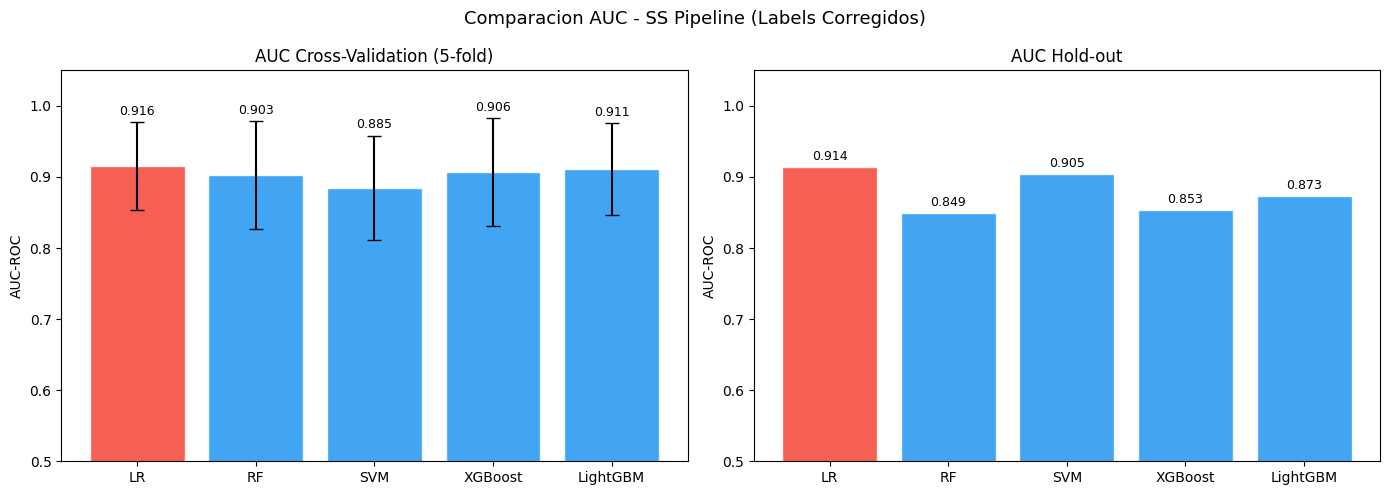

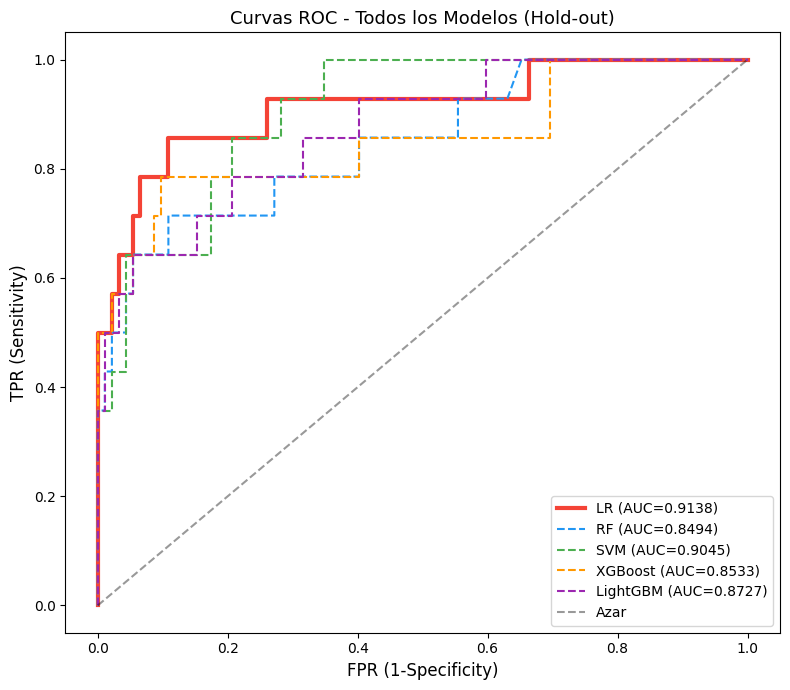

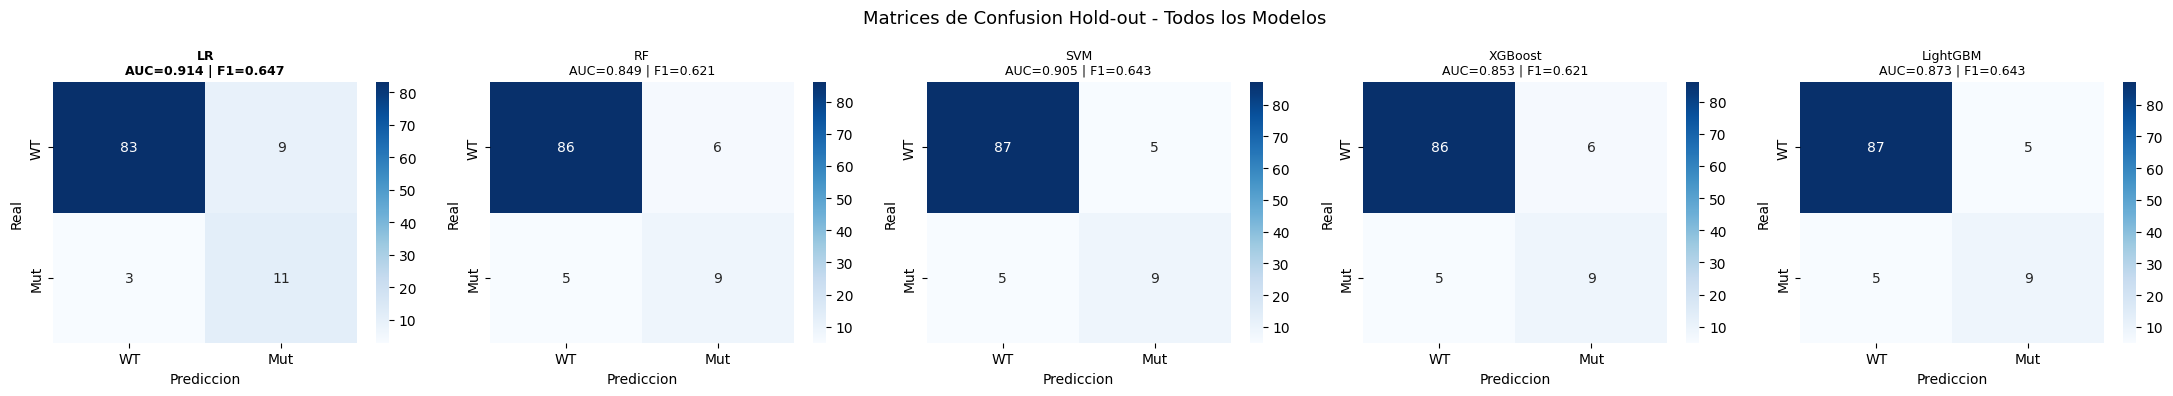

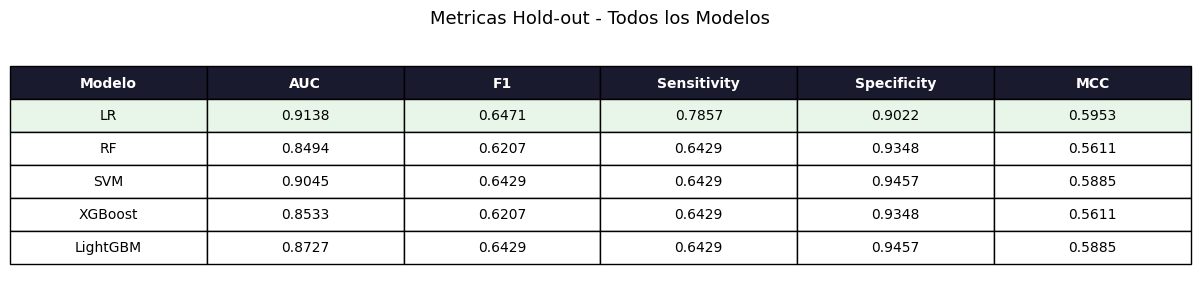

Todas las figuras guardadas.


In [ ]:
# CELDA 12
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, recall_score
)

BASE_DRIVE = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR     = BASE_DRIVE / 'SS_PIPELINE'
SS_CLF     = SS_DIR / 'clasificador_v2'

RANDOM_STATE = 42
N_SPLITS     = 5

# ============================================================
# PASO 1 - Cargar datos, modelos y resultados
# ============================================================
with open(SS_DIR / 'ss_radiomics_config.json') as f:
    rad_config = json.load(f)
feat_names = rad_config['feature_names']

feat_path    = SS_DIR / 'radiomics/selected_features/features_selected.csv'
labels_path  = BASE_DRIVE / 'Dataset/labels_idh_corregido.csv'
df_feat_orig = pd.read_csv(str(feat_path))
df_labels    = pd.read_csv(str(labels_path), sep=';')
df_labels.columns = df_labels.columns.str.strip()

casos_validos = df_labels['caso'].tolist()
df_data       = df_feat_orig[df_feat_orig['subject_id'].isin(casos_validos)].copy()

X    = df_data[feat_names].values
y    = df_data['idh_status'].values
sids = df_data['subject_id'].values

df_holdout_ids = pd.read_csv(str(SS_CLF / 'results/holdout_ids.csv'))
hold_mask = df_data['subject_id'].isin(df_holdout_ids['subject_id'])
dev_mask  = ~hold_mask

X_hold = X[hold_mask]
y_hold = y[hold_mask]
X_dev  = X[dev_mask]
y_dev  = y[dev_mask]

print(f'Desarrollo : {len(y_dev)} casos')
print(f'Hold-out   : {len(y_hold)} casos')

# Cargar modelos
model_names = ['LR', 'RF', 'SVM', 'XGBoost', 'LightGBM']
models = {}
for name in model_names:
    models[name] = joblib.load(str(SS_CLF / f'models/{name}.joblib'))
print(f'Modelos cargados: {list(models.keys())}')

# Cargar resultados CV
df_cv = pd.read_csv(str(SS_CLF / 'results/cv_results.csv'), index_col=0)
cv_results = df_cv.to_dict(orient='index')

# Cargar holdout metrics - AUC está como índice
df_holdout = pd.read_csv(str(SS_CLF / 'results/holdout_metrics.csv'), index_col=0)
print(f'\nHoldout index: {df_holdout.index.tolist()}')
print(df_holdout.to_string())

# Reconstruir holdout_results recalculando desde los modelos
holdout_results = {}
for name, model in models.items():
    y_prob = model.predict_proba(X_hold)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_hold, y_pred).ravel()
    holdout_results[name] = {
        'auc'        : float(roc_auc_score(y_hold, y_prob)),
        'f1'         : float(f1_score(y_hold, y_pred)),
        'recall'     : float(recall_score(y_hold, y_pred)),
        'specificity': float(tn / (tn + fp + 1e-8)),
        'mcc'        : float(__import__('sklearn.metrics', fromlist=['matthews_corrcoef'])
                             .matthews_corrcoef(y_hold, y_pred)),
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
    }
    print(f'{name}: AUC={holdout_results[name]["auc"]:.4f} | '
          f'F1={holdout_results[name]["f1"]:.4f}')

best_model_name = df_cv['auc_mean'].idxmax()
best_name       = max(holdout_results, key=lambda n: holdout_results[n]['auc'])
print(f'\nMejor modelo CV      : {best_model_name}')
print(f'Mejor modelo Hold-out: {best_name}')

# ============================================================
# FIGURA 1 - Comparacion AUC CV y Hold-out
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres     = list(cv_results.keys())
aucs_cv     = [cv_results[n]['auc_mean'] for n in nombres]
stds_cv     = [cv_results[n]['auc_std']  for n in nombres]
aucs_hold   = [holdout_results[n]['auc'] for n in nombres]
colors_cv   = ['#F44336' if n == best_model_name else '#2196F3' for n in nombres]
colors_hold = ['#F44336' if n == best_name       else '#2196F3' for n in nombres]

axes[0].bar(nombres, aucs_cv, yerr=stds_cv, color=colors_cv,
            alpha=0.85, edgecolor='white', capsize=5)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('AUC Cross-Validation (5-fold)')
axes[0].set_ylabel('AUC-ROC')
for i, (v, s) in enumerate(zip(aucs_cv, stds_cv)):
    axes[0].text(i, v + s + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(nombres, aucs_hold, color=colors_hold, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('AUC Hold-out')
axes[1].set_ylabel('AUC-ROC')
for i, v in enumerate(aucs_hold):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparacion AUC - SS Pipeline (Labels Corregidos)', fontsize=13)
plt.tight_layout()
plt.savefig(SS_CLF / 'figures/auc_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2 - Curvas ROC todos los modelos (Hold-out)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
colores_roc = ['#F44336', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for (name, model), color in zip(models.items(), colores_roc):
    y_prob = model.predict_proba(X_hold)[:, 1]
    fpr, tpr, _ = roc_curve(y_hold, y_prob)
    auc_val = roc_auc_score(y_hold, y_prob)
    lw = 3 if name == best_name else 1.5
    ls = '-' if name == best_name else '--'
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls,
            label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Azar')
ax.set_xlabel('FPR (1-Specificity)', fontsize=12)
ax.set_ylabel('TPR (Sensitivity)', fontsize=12)
ax.set_title('Curvas ROC - Todos los Modelos (Hold-out)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(SS_CLF / 'figures/roc_todos_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 3 - Matrices de confusion todos los modelos (Hold-out)
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_prob = model.predict_proba(X_hold)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    cm     = confusion_matrix(y_hold, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['WT', 'Mut'],
                yticklabels=['WT', 'Mut'])
    auc_val = roc_auc_score(y_hold, y_prob)
    f1_val  = f1_score(y_hold, y_pred)
    ax.set_title(f'{name}\nAUC={auc_val:.3f} | F1={f1_val:.3f}',
                 fontsize=9,
                 fontweight='bold' if name == best_name else 'normal')
    ax.set_ylabel('Real')
    ax.set_xlabel('Prediccion')

plt.suptitle('Matrices de Confusion Hold-out - Todos los Modelos', fontsize=13)
plt.tight_layout()
plt.savefig(SS_CLF / 'figures/confusion_matrices_holdout.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 4 - Tabla resumen metricas hold-out
# ============================================================
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
headers    = ['Modelo', 'AUC', 'F1', 'Sensitivity', 'Specificity', 'MCC']
tabla_data = []
for name in nombres:
    r = holdout_results[name]
    tabla_data.append([
        name,
        f'{r["auc"]:.4f}',
        f'{r["f1"]:.4f}',
        f'{r["recall"]:.4f}',
        f'{r["specificity"]:.4f}',
        f'{r["mcc"]:.4f}',
    ])
tabla = ax.table(cellText=tabla_data, colLabels=headers,
                 loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2)
for j in range(len(headers)):
    tabla[0, j].set_facecolor('#1a1a2e')
    tabla[0, j].set_text_props(color='white', fontweight='bold')
for i, name in enumerate(nombres):
    if name == best_name:
        for j in range(len(headers)):
            tabla[i+1, j].set_facecolor('#e8f5e9')
plt.title('Metricas Hold-out - Todos los Modelos', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(SS_CLF / 'figures/tabla_metricas_holdout.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Todas las figuras guardadas.')